# BDI Layer - Scenario-Specific Model Training
## Train Separate Models for Each Scenario | Test on Fusion Dataset

This notebook trains individual ML classifiers for each driving scenario (Danger Zone, Overtaking, Intersection) and evaluates their performance on the Fusion dataset.

## 1. Import Required Libraries

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score, precision_recall_curve
)
from sklearn.model_selection import cross_val_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Datasets

In [50]:
# Define paths
import os
base_path = os.path.dirname(os.path.abspath('.'))

# Load the three scenario datasets
print("Loading scenario-specific datasets...")
dz_path = '../dataset_apres_smote_DZ.csv'
overtaking_path = '../dataset_apres_smote_overtaking.csv'
intersection_path = '../dataset_apres_smote_intersection.csv'
fusion_path = '../Fusion_dataset.csv'

# Load datasets
df_dz = pd.read_csv(dz_path)
df_overtaking = pd.read_csv(overtaking_path)
df_intersection = pd.read_csv(intersection_path)
df_fusion = pd.read_csv(fusion_path)

print(f"Danger Zone dataset shape: {df_dz.shape}")
print(f"Overtaking dataset shape: {df_overtaking.shape}")
print(f"Intersection dataset shape: {df_intersection.shape}")
print(f"Fusion dataset shape: {df_fusion.shape}")
print("\nDatasets loaded successfully!")

Loading scenario-specific datasets...
Danger Zone dataset shape: (25689, 19)
Overtaking dataset shape: (33778, 17)
Intersection dataset shape: (47788, 15)
Fusion dataset shape: (103643, 26)

Datasets loaded successfully!


## 3. Prepare Data for Each Scenario

In [51]:
# Define feature engineering function
def prepare_scenario_data(df, scenario_name):
    """
    Prepare data for a specific scenario with feature engineering
    """
    df_clean = df.copy()
    
    # Compute deceleration from acceleration where missing
    if 'Deceleration' in df_clean.columns:
        mask_missing = df_clean['Deceleration'].isnull()
        df_clean.loc[mask_missing, 'Deceleration'] = df_clean.loc[mask_missing, 'Acceleration'].apply(lambda a: -a if a < 0 else 0)
    
    # Compute RelativeSpeed from Speed and LeaderSpeed where missing
    if 'RelativeSpeed' in df_clean.columns and 'Speed' in df_clean.columns and 'LeaderSpeed' in df_clean.columns:
        mask_missing = df_clean['RelativeSpeed'].isnull()
        df_clean.loc[mask_missing, 'RelativeSpeed'] = df_clean.loc[mask_missing, 'Speed'] - df_clean.loc[mask_missing, 'LeaderSpeed']
    
    # Compute TTC (Time To Collision) from LeaderGap and RelativeSpeed where missing
    def compute_ttc(row):
        if pd.isna(row.get('LeaderGap')) or pd.isna(row.get('RelativeSpeed')) or row.get('LeaderGap', -1) <= 0:
            return 999.0
        if row['RelativeSpeed'] <= 0:
            return 999.0
        return row['LeaderGap'] / row['RelativeSpeed']
    
    if 'TTC' in df_clean.columns and 'LeaderGap' in df_clean.columns and 'RelativeSpeed' in df_clean.columns:
        mask_missing = df_clean['TTC'].isnull()
        df_clean.loc[mask_missing, 'TTC'] = df_clean.loc[mask_missing].apply(compute_ttc, axis=1)
    
    # Fill remaining numeric missing values with mean
    numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
    numeric_cols = [col for col in numeric_cols if col not in ['Time', 'VehicleId', 'Pos_x', 'Pos_y']]
    for col in numeric_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mean())
    
    # Fill boolean columns with False (0)
    boolean_cols = ['hard_brake', 'danger_accel_toward_leader', 'leader_stopped', 'no_reaction_to_stopped_leader', 'lane_opposite_change']
    for col in boolean_cols:
        if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
            df_clean[col] = df_clean[col].fillna(0)
    
    print(f"\n{scenario_name} Dataset Preparation:")
    print(f"  Shape: {df_clean.shape}")
    missing_count = df_clean.isnull().sum().sum()
    print(f"  Remaining missing values: {missing_count}")
    
    return df_clean

# Prepare each scenario dataset
df_dz_clean = prepare_scenario_data(df_dz, "Danger Zone")
df_overtaking_clean = prepare_scenario_data(df_overtaking, "Overtaking")
df_intersection_clean = prepare_scenario_data(df_intersection, "Intersection")
df_fusion_clean = prepare_scenario_data(df_fusion, "Fusion")


Danger Zone Dataset Preparation:
  Shape: (25689, 19)
  Remaining missing values: 0

Overtaking Dataset Preparation:
  Shape: (33778, 17)
  Remaining missing values: 0

Intersection Dataset Preparation:
  Shape: (47788, 15)
  Remaining missing values: 0

Fusion Dataset Preparation:
  Shape: (103643, 26)
  Remaining missing values: 49569


## 4. Extract Features for Model Training

In [52]:
# Define features to use
exclude_cols = ['Time', 'VehicleId', 'scenario', 'Pos_x', 'Pos_y']

# Also exclude target columns to prevent data leakage
target_cols = ['SafeDangerZone', 'SafeUnsafeOvertaking', 'SafeUnsafeCrossing', 'SafetyRating', 'IsAccidentCase']
exclude_cols.extend(target_cols)

# Identify numeric features
all_cols = df_dz_clean.columns
feature_cols = [col for col in all_cols 
                 if col not in exclude_cols and df_dz_clean[col].dtype in ['int64', 'float64']]

# Identify boolean columns (only those that exist)
boolean_cols = [col for col in all_cols 
                if (df_dz_clean[col].dtype == 'bool' or 
                    col in ['hard_brake', 'danger_accel_toward_leader', 'leader_stopped', 'no_reaction_to_stopped_leader']) 
                and col not in exclude_cols]

feature_cols = [col for col in feature_cols if col not in boolean_cols] + boolean_cols

print(f"Selected features ({len(feature_cols)}):")
print(feature_cols)

Selected features (14):
['Speed', 'Lane', 'Acceleration', 'LeaderID', 'LeaderSpeed', 'LeaderGap', 'Deceleration', 'RelativeSpeed', 'TTC', 'SafeDistance', 'hard_brake', 'danger_accel_toward_leader', 'leader_stopped', 'no_reaction_to_stopped_leader']


In [53]:
# Check what columns are available in each dataset
print("Danger Zone columns:", sorted(df_dz_clean.columns.tolist()))
print("\nOvertaking columns:", sorted(df_overtaking_clean.columns.tolist()))
print("\nIntersection columns:", sorted(df_intersection_clean.columns.tolist()))
print("\nFusion columns:", sorted(df_fusion_clean.columns.tolist()))

Danger Zone columns: ['Acceleration', 'Deceleration', 'Lane', 'LeaderGap', 'LeaderID', 'LeaderSpeed', 'Pos_x', 'Pos_y', 'RelativeSpeed', 'SafeDangerZone', 'SafeDistance', 'Speed', 'TTC', 'Time', 'VehicleId', 'danger_accel_toward_leader', 'hard_brake', 'leader_stopped', 'no_reaction_to_stopped_leader']

Overtaking columns: ['Acceleration', 'Deceleration', 'Lane', 'LanePrev', 'LeaderGap', 'LeaderID', 'LeaderSpeed', 'Pos_x', 'Pos_y', 'RelativeSpeed', 'SafeDistance', 'SafeUnsafeOvertaking', 'Speed', 'TTC', 'Time', 'VehicleId', 'lane_opposite_change']

Intersection columns: ['Acceleration', 'Deceleration', 'Lane', 'LeaderGap', 'LeaderID', 'LeaderSpeed', 'Pos_x', 'Pos_y', 'RelativeSpeed', 'SafeDistance', 'SafeUnsafeCrossing', 'Speed', 'TTC', 'Time', 'VehicleId']

Fusion columns: ['Acceleration', 'AccidentTypes', 'Deceleration', 'IsAccidentCase', 'Lane', 'LanePrev', 'LeaderGap', 'LeaderID', 'LeaderSpeed', 'Pos_x', 'Pos_y', 'RelativeSpeed', 'SafeDangerZone', 'SafeDistance', 'SafeUnsafeCrossing

## 5. Train Scenario-Specific Models

In [54]:
# Dictionary to store results
scenario_models = {}
scenario_scalers = {}
scenario_results = {}

scenarios = {
    'danger_zone': df_dz_clean,
    'overtaking': df_overtaking_clean,
    'intersection': df_intersection_clean
}

for scenario_name, df_data in scenarios.items():
    print(f"\n{'='*60}")
    print(f"Training model for: {scenario_name.upper()}")
    print(f"{'='*60}")

    # Define features for this specific scenario
    exclude_cols = ['Time', 'VehicleId', 'scenario', 'Pos_x', 'Pos_y']

    # Define target columns to exclude from features
    target_cols = ['SafeDangerZone', 'SafeUnsafeOvertaking', 'SafeUnsafeCrossing', 'SafetyRating', 'IsAccidentCase']
    exclude_cols.extend(target_cols)

    all_cols = df_data.columns
    numeric_features = [
        col for col in all_cols
        if col not in exclude_cols and df_data[col].dtype in ['int64', 'float64']
    ]
    boolean_features = [
        col for col in all_cols
        if (df_data[col].dtype == 'bool' or
            col in ['hard_brake', 'danger_accel_toward_leader', 'leader_stopped',
                    'no_reaction_to_stopped_leader', 'lane_opposite_change'])
        and col not in exclude_cols
    ]
    feature_cols = [col for col in numeric_features if col not in boolean_features] + boolean_features

    print(f"Features for {scenario_name}: {len(feature_cols)} - {feature_cols}")

    # Prepare features and target
    X = df_data[feature_cols].copy()

    if scenario_name == 'danger_zone' and 'SafeDangerZone' in df_data.columns:
        y = pd.to_numeric(df_data['SafeDangerZone'], errors='coerce')
    elif scenario_name == 'overtaking' and 'SafeUnsafeOvertaking' in df_data.columns:
        y = pd.to_numeric(df_data['SafeUnsafeOvertaking'], errors='coerce')
    elif scenario_name == 'intersection' and 'SafeUnsafeCrossing' in df_data.columns:
        y = pd.to_numeric(df_data['SafeUnsafeCrossing'], errors='coerce')
    else:
        if 'hard_brake' in df_data.columns:
            y = (df_data['hard_brake'] == 1).astype(int)
        else:
            y = pd.Series([0] * len(X), index=X.index)
            print("Warning: No suitable target column found, using dummy target")

    # Remove NaN rows in either X or y
    valid_idx = ~(X.isnull().any(axis=1) | y.isnull())
    X = X[valid_idx].copy()
    y = y[valid_idx].astype(int).copy()

    print(f"Training samples: {len(X)}")
    print(f"Safety distribution: {y.value_counts().to_dict()}")

    train_time_max = None
    train_time_min = None

    # Split data with leakage-aware grouping when possible
    if 'VehicleId' in df_data.columns:
        groups = df_data.loc[valid_idx, 'VehicleId'].copy()
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, val_idx = next(gss.split(X, y, groups=groups))
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        train_vehicle_ids = set(groups.iloc[train_idx].astype(str))
        val_vehicle_ids = set(groups.iloc[val_idx].astype(str))
        print("Split method: GroupShuffleSplit by VehicleId")
        print(f"Train vehicles: {len(train_vehicle_ids)}, Val vehicles: {len(val_vehicle_ids)}")
    else:
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        train_vehicle_ids = None
        val_vehicle_ids = None
        print("Split method: Stratified random split")

    if 'Time' in df_data.columns:
        time_series = pd.to_numeric(df_data.loc[valid_idx, 'Time'], errors='coerce')
        train_time_max = float(time_series.iloc[train_idx].max()) if 'train_idx' in locals() else float(time_series.max())
        train_time_min = float(time_series.iloc[train_idx].min()) if 'train_idx' in locals() else float(time_series.min())

    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # More regularized RF to reduce overfitting
    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=20,
        min_samples_split=40,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train_scaled, y_train)

    # Evaluate on validation set
    y_pred = rf_model.predict(X_val_scaled)

    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    print(f"\nValidation Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    scenario_models[scenario_name] = rf_model
    scenario_scalers[scenario_name] = scaler
    scenario_results[scenario_name] = {
        'model': rf_model,
        'scaler': scaler,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'feature_cols': feature_cols,
        'train_vehicle_ids': train_vehicle_ids,
        'val_vehicle_ids': val_vehicle_ids,
        'train_time_min': train_time_min,
        'train_time_max': train_time_max,
        'train_row_count': int(len(X_train)),
        'val_row_count': int(len(X_val))
    }

print(f"\n{'='*60}")
print("All scenario-specific models trained successfully!")
print(f"{'='*60}")


Training model for: DANGER_ZONE
Features for danger_zone: 14 - ['Speed', 'Lane', 'Acceleration', 'LeaderID', 'LeaderSpeed', 'LeaderGap', 'Deceleration', 'RelativeSpeed', 'TTC', 'SafeDistance', 'hard_brake', 'danger_accel_toward_leader', 'leader_stopped', 'no_reaction_to_stopped_leader']
Training samples: 25689
Safety distribution: {1: 14272, 0: 11417}
Split method: GroupShuffleSplit by VehicleId
Train vehicles: 58, Val vehicles: 15

Validation Metrics:
  Accuracy:  0.9997
  Precision: 0.9993
  Recall:    1.0000
  F1-Score:  0.9996

Training model for: OVERTAKING
Features for overtaking: 12 - ['Speed', 'Lane', 'LeaderID', 'LeaderSpeed', 'LeaderGap', 'Acceleration', 'Deceleration', 'RelativeSpeed', 'TTC', 'SafeDistance', 'LanePrev', 'lane_opposite_change']
Training samples: 33778
Safety distribution: {0: 18766, 1: 15012}
Split method: GroupShuffleSplit by VehicleId
Train vehicles: 58, Val vehicles: 15

Validation Metrics:
  Accuracy:  0.9944
  Precision: 0.9850
  Recall:    0.9914
  F1-

## 6. Test Models on Fusion Dataset

In [55]:
# Evaluate each scenario model on the corresponding Fusion scenario subset
target_map = {
    'danger_zone': 'SafeDangerZone',
    'overtaking': 'SafeUnsafeOvertaking',
    'intersection': 'SafeUnsafeCrossing'
}

print(f"\n{'='*60}")
print("Testing Scenario-Specific Models on Matching Fusion Subsets")
print(f"{'='*60}")
print(f"Total Fusion samples: {len(df_fusion_clean)}")

fusion_predictions = {}
fusion_scores = {}

for scenario_name, model_info in scenario_results.items():
    print(f"\n--- Testing {scenario_name} model ---")

    model = model_info['model']
    scaler = model_info['scaler']
    model_features = model_info['feature_cols']
    target_col = target_map.get(scenario_name)

    # 1) Filter Fusion rows to the same scenario used to train this model
    if 'Scenario' in df_fusion_clean.columns:
        df_subset = df_fusion_clean[df_fusion_clean['Scenario'] == scenario_name].copy()
    else:
        print("Warning: 'Scenario' column not found in Fusion dataset. Using all rows.")
        df_subset = df_fusion_clean.copy()

    if df_subset.empty:
        print(f"Warning: No Fusion rows found for scenario '{scenario_name}'.")
        continue

    # 2) Keep only unseen vehicles (not used in training), when VehicleId is available
    if 'VehicleId' in df_subset.columns and model_info.get('train_vehicle_ids') is not None:
        before_count = len(df_subset)
        train_vehicle_ids = model_info['train_vehicle_ids']
        df_subset = df_subset[~df_subset['VehicleId'].astype(str).isin(train_vehicle_ids)].copy()
        after_count = len(df_subset)
        print(f"Unseen-vehicle filter: {before_count} -> {after_count} rows")

    # 3) Stronger holdout: evaluate on future time segment when possible
    if 'Time' in df_subset.columns and len(df_subset) > 100:
        df_subset['Time_num'] = pd.to_numeric(df_subset['Time'], errors='coerce')
        df_subset = df_subset.dropna(subset=['Time_num']).copy()
        if len(df_subset) > 100:
            t_cut = df_subset['Time_num'].quantile(0.8)
            before_time = len(df_subset)
            df_subset = df_subset[df_subset['Time_num'] >= t_cut].copy()
            print(f"Future-time filter (top 20% Time): {before_time} -> {len(df_subset)} rows")

    if df_subset.empty:
        print("Warning: No rows left after strict filtering; skipping this scenario.")
        continue

    # 4) Build feature matrix with exact training feature names/order
    X_fusion_test = df_subset.reindex(columns=model_features).copy()
    missing_features = [col for col in model_features if col not in df_subset.columns]
    if missing_features:
        print(f"Warning: Missing features in Fusion subset for {scenario_name}: {missing_features}")
        print("Filling missing feature columns with 0.")

    # Fill NaN values: first with column means, then fallback to 0
    X_fusion_test = X_fusion_test.apply(pd.to_numeric, errors='coerce')
    X_fusion_test = X_fusion_test.fillna(X_fusion_test.mean(numeric_only=True)).fillna(0)

    print(f"Subset samples used for test: {len(X_fusion_test)}")
    print(f"Using {len(model_features)} model features")

    # 5) Predict
    try:
        X_fusion_scaled = scaler.transform(X_fusion_test)
        y_pred = model.predict(X_fusion_scaled)
        y_pred_proba = model.predict_proba(X_fusion_scaled)

        fusion_predictions[scenario_name] = y_pred
        fusion_scores[scenario_name] = y_pred_proba
        print(f"Predictions generated: {len(y_pred)} samples")
    except Exception as e:
        print(f"Error testing {scenario_name} model: {str(e)}")
        continue

    # 6) Evaluate with the matching target column
    if target_col in df_subset.columns:
        y_true = pd.to_numeric(df_subset[target_col], errors='coerce')
        valid_idx = ~y_true.isnull()

        if valid_idx.sum() > 0:
            y_true_valid = y_true[valid_idx].astype(int)
            y_pred_valid = y_pred[valid_idx.values]

            accuracy = accuracy_score(y_true_valid, y_pred_valid)
            precision = precision_score(y_true_valid, y_pred_valid, zero_division=0)
            recall = recall_score(y_true_valid, y_pred_valid, zero_division=0)
            f1 = f1_score(y_true_valid, y_pred_valid, zero_division=0)

            print(f"  Accuracy:  {accuracy:.4f}")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall:    {recall:.4f}")
            print(f"  F1-Score:  {f1:.4f}")
        else:
            print(f"Warning: No valid labels found in {target_col} for scenario {scenario_name}")
    else:
        print(f"Warning: Target column '{target_col}' not found in Fusion subset")

    # 7) Show prediction distribution
    pred_dist = pd.Series(y_pred).value_counts()
    print(f"  Prediction distribution: {pred_dist.to_dict()}")

print(f"\n{'='*60}")
print("All scenario-specific models tested on strict matching Fusion subsets!")
print(f"{'='*60}")


Testing Scenario-Specific Models on Matching Fusion Subsets
Total Fusion samples: 103643

--- Testing danger_zone model ---
Unseen-vehicle filter: 25689 -> 3891 rows
Future-time filter (top 20% Time): 3891 -> 780 rows
Subset samples used for test: 780
Using 14 model features
Predictions generated: 780 samples
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Prediction distribution: {0: 535, 1: 245}

--- Testing overtaking model ---
Unseen-vehicle filter: 33778 -> 3922 rows
Future-time filter (top 20% Time): 3922 -> 785 rows
Subset samples used for test: 785
Using 12 model features
Predictions generated: 785 samples
  Accuracy:  0.9936
  Precision: 0.9355
  Recall:    0.9831
  F1-Score:  0.9587
  Prediction distribution: {0: 723, 1: 62}

--- Testing intersection model ---
Unseen-vehicle filter: 44176 -> 8462 rows
Future-time filter (top 20% Time): 8462 -> 1693 rows
Subset samples used for test: 1693
Using 10 model features
Predictions generated: 1693 sa

## 6.1 Root Cause Diagnostics
This diagnostic checks whether train and test are still too similar by measuring exact feature-row overlap between each scenario dataset and its Fusion subset after strict filtering. High overlap means leakage-like behavior and inflated metrics.

In [56]:
# Root-cause diagnostics: overlap between scenario-train source and strict fusion test subset
diag_rows = []

target_map = {
    'danger_zone': 'SafeDangerZone',
    'overtaking': 'SafeUnsafeOvertaking',
    'intersection': 'SafeUnsafeCrossing'
}

scenario_df_map = {
    'danger_zone': df_dz_clean,
    'overtaking': df_overtaking_clean,
    'intersection': df_intersection_clean
}

for scenario_name, model_info in scenario_results.items():
    feature_cols = model_info['feature_cols']
    source_df = scenario_df_map[scenario_name].copy()
    fusion_subset = df_fusion_clean[df_fusion_clean['Scenario'] == scenario_name].copy()

    # Keep unseen vehicles only where possible
    if 'VehicleId' in fusion_subset.columns and model_info.get('train_vehicle_ids') is not None:
        fusion_subset = fusion_subset[~fusion_subset['VehicleId'].astype(str).isin(model_info['train_vehicle_ids'])].copy()

    # Keep future-time window (top 20%) where possible
    if 'Time' in fusion_subset.columns and len(fusion_subset) > 100:
        fusion_subset['Time_num'] = pd.to_numeric(fusion_subset['Time'], errors='coerce')
        fusion_subset = fusion_subset.dropna(subset=['Time_num']).copy()
        if len(fusion_subset) > 100:
            t_cut = fusion_subset['Time_num'].quantile(0.8)
            fusion_subset = fusion_subset[fusion_subset['Time_num'] >= t_cut].copy()

    # Build comparable feature frames
    train_feat = source_df.reindex(columns=feature_cols).copy()
    test_feat = fusion_subset.reindex(columns=feature_cols).copy()

    train_feat = train_feat.apply(pd.to_numeric, errors='coerce').fillna(0)
    test_feat = test_feat.apply(pd.to_numeric, errors='coerce').fillna(0)

    # Exact row-overlap proxy
    if len(test_feat) > 0 and len(train_feat) > 0:
        train_hash = pd.util.hash_pandas_object(train_feat, index=False)
        test_hash = pd.util.hash_pandas_object(test_feat, index=False)
        overlap_count = int(test_hash.isin(set(train_hash)).sum())
        overlap_ratio = overlap_count / len(test_feat)
    else:
        overlap_count = 0
        overlap_ratio = np.nan

    diag_rows.append({
        'Scenario': scenario_name,
        'TrainRows': len(train_feat),
        'StrictTestRows': len(test_feat),
        'ExactFeatureRowOverlapCount': overlap_count,
        'ExactFeatureRowOverlapRatio': overlap_ratio,
        'TrainTimeMin': model_info.get('train_time_min'),
        'TrainTimeMax': model_info.get('train_time_max')
    })

diag_df = pd.DataFrame(diag_rows)
print("\nROOT-CAUSE DIAGNOSTIC SUMMARY")
print("=" * 100)
print(diag_df.to_string(index=False))
print("=" * 100)

print("\nInterpretation guide:")
print("- Overlap ratio close to 0.0: low exact duplication")
print("- Overlap ratio high (e.g., >0.1): strong duplication/leakage signal")
print("- Very small StrictTestRows means metrics are unstable and less representative")


ROOT-CAUSE DIAGNOSTIC SUMMARY
    Scenario  TrainRows  StrictTestRows  ExactFeatureRowOverlapCount  ExactFeatureRowOverlapRatio  TrainTimeMin  TrainTimeMax
 danger_zone      25689             780                            0                          0.0           0.0         149.6
  overtaking      33778             785                            0                          0.0           0.0         129.9
intersection      47788            1693                            0                          0.0           0.0         200.0

Interpretation guide:
- Overlap ratio close to 0.0: low exact duplication
- Overlap ratio high (e.g., >0.1): strong duplication/leakage signal
- Very small StrictTestRows means metrics are unstable and less representative


## 6.2 Label Determinism Check
This check trains a very shallow Decision Tree (max_depth=2) per scenario and evaluates it on the same strict subset (unseen vehicles + future time). If this tiny model gets very high scores, the target is likely mostly rule-based from existing features.

In [57]:
from sklearn.tree import DecisionTreeClassifier

determinism_rows = []

target_map = {
    'danger_zone': 'SafeDangerZone',
    'overtaking': 'SafeUnsafeOvertaking',
    'intersection': 'SafeUnsafeCrossing'
}

scenario_df_map = {
    'danger_zone': df_dz_clean,
    'overtaking': df_overtaking_clean,
    'intersection': df_intersection_clean
}

for scenario_name, model_info in scenario_results.items():
    feature_cols = model_info['feature_cols']
    target_col = target_map[scenario_name]

    # Train source
    source_df = scenario_df_map[scenario_name].copy()
    X_train = source_df.reindex(columns=feature_cols).apply(pd.to_numeric, errors='coerce').fillna(0)
    y_train = pd.to_numeric(source_df[target_col], errors='coerce').fillna(0).astype(int)

    # Strict test subset from Fusion
    df_subset = df_fusion_clean[df_fusion_clean['Scenario'] == scenario_name].copy()
    if 'VehicleId' in df_subset.columns and model_info.get('train_vehicle_ids') is not None:
        df_subset = df_subset[~df_subset['VehicleId'].astype(str).isin(model_info['train_vehicle_ids'])].copy()
    if 'Time' in df_subset.columns and len(df_subset) > 100:
        df_subset['Time_num'] = pd.to_numeric(df_subset['Time'], errors='coerce')
        df_subset = df_subset.dropna(subset=['Time_num']).copy()
        if len(df_subset) > 100:
            t_cut = df_subset['Time_num'].quantile(0.8)
            df_subset = df_subset[df_subset['Time_num'] >= t_cut].copy()

    if df_subset.empty or target_col not in df_subset.columns:
        determinism_rows.append({
            'Scenario': scenario_name,
            'StrictRows': 0,
            'Depth2_Accuracy': np.nan,
            'Depth2_F1': np.nan
        })
        continue

    X_test = df_subset.reindex(columns=feature_cols).apply(pd.to_numeric, errors='coerce').fillna(0)
    y_test = pd.to_numeric(df_subset[target_col], errors='coerce')
    valid = ~y_test.isnull()
    X_test = X_test[valid]
    y_test = y_test[valid].astype(int)

    if len(X_test) == 0:
        determinism_rows.append({
            'Scenario': scenario_name,
            'StrictRows': 0,
            'Depth2_Accuracy': np.nan,
            'Depth2_F1': np.nan
        })
        continue

    shallow = DecisionTreeClassifier(max_depth=2, random_state=42)
    shallow.fit(X_train, y_train)
    y_pred_shallow = shallow.predict(X_test)

    acc = accuracy_score(y_test, y_pred_shallow)
    f1 = f1_score(y_test, y_pred_shallow, zero_division=0)

    determinism_rows.append({
        'Scenario': scenario_name,
        'StrictRows': int(len(X_test)),
        'Depth2_Accuracy': float(acc),
        'Depth2_F1': float(f1)
    })

determinism_df = pd.DataFrame(determinism_rows)
print("\nLABEL DETERMINISM (SHALLOW TREE) SUMMARY")
print("=" * 90)
print(determinism_df.to_string(index=False))
print("=" * 90)

print("\nInterpretation guide:")
print("- If Depth2 metrics are very high, labels are almost directly encoded by a few features")
print("- If Depth2 metrics are low but RF is high, RF is using more complex interactions")


LABEL DETERMINISM (SHALLOW TREE) SUMMARY
    Scenario  StrictRows  Depth2_Accuracy  Depth2_F1
 danger_zone         780         0.996154   0.993915
  overtaking         785         0.978344   0.852174
intersection        1693         0.990549   0.990783

Interpretation guide:
- If Depth2 metrics are very high, labels are almost directly encoded by a few features
- If Depth2 metrics are low but RF is high, RF is using more complex interactions


## 6.3 Feature Ablation Stress Test
This test retrains each scenario model after removing likely proxy features and the model's top-importance features. A large drop in strict-test F1 indicates that the original high scores were driven by a small set of shortcut features rather than broad generalization.

In [58]:
# Feature ablation stress test: identify shortcut/proxy feature reliance
from sklearn.ensemble import RandomForestClassifier

proxy_candidates = [
    'hard_brake',
    'danger_accel_toward_leader',
    'leader_stopped',
    'no_reaction_to_stopped_leader',
    'lane_opposite_change'
]

target_map = {
    'danger_zone': 'SafeDangerZone',
    'overtaking': 'SafeUnsafeOvertaking',
    'intersection': 'SafeUnsafeCrossing'
}

scenario_df_map = {
    'danger_zone': df_dz_clean,
    'overtaking': df_overtaking_clean,
    'intersection': df_intersection_clean
}

def get_strict_subset(df_fusion_src, scenario_name, model_info):
    subset = df_fusion_src[df_fusion_src['Scenario'] == scenario_name].copy()

    if 'VehicleId' in subset.columns and model_info.get('train_vehicle_ids') is not None:
        subset = subset[~subset['VehicleId'].astype(str).isin(model_info['train_vehicle_ids'])].copy()

    if 'Time' in subset.columns and len(subset) > 100:
        subset['Time_num'] = pd.to_numeric(subset['Time'], errors='coerce')
        subset = subset.dropna(subset=['Time_num']).copy()
        if len(subset) > 100:
            t_cut = subset['Time_num'].quantile(0.8)
            subset = subset[subset['Time_num'] >= t_cut].copy()

    return subset

def eval_strict_f1(model, scaler, features, strict_subset, target_col):
    if strict_subset.empty or target_col not in strict_subset.columns:
        return np.nan, 0

    X_test = strict_subset.reindex(columns=features).copy()
    X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)
    y_true = pd.to_numeric(strict_subset[target_col], errors='coerce')
    valid = ~y_true.isnull()

    if valid.sum() == 0:
        return np.nan, 0

    X_test = X_test[valid]
    y_true = y_true[valid].astype(int)

    y_pred = model.predict(scaler.transform(X_test))
    return float(f1_score(y_true, y_pred, zero_division=0)), int(len(y_true))

ablation_rows = []

for scenario_name, model_info in scenario_results.items():
    target_col = target_map[scenario_name]
    source_df = scenario_df_map[scenario_name].copy()
    strict_subset = get_strict_subset(df_fusion_clean, scenario_name, model_info)

    base_features = list(model_info['feature_cols'])
    base_model = model_info['model']
    base_scaler = model_info['scaler']

    baseline_f1, strict_rows = eval_strict_f1(
        base_model, base_scaler, base_features, strict_subset, target_col
    )

    # Remove likely proxy booleans if present
    removed_proxy = [c for c in proxy_candidates if c in base_features]

    # Remove top-importance features from the trained RF
    importance_series = pd.Series(base_model.feature_importances_, index=base_features).sort_values(ascending=False)
    top_k = min(5, len(importance_series))
    removed_top = importance_series.head(top_k).index.tolist()

    remove_set = set(removed_proxy + removed_top)
    ablated_features = [c for c in base_features if c not in remove_set]

    if len(ablated_features) < 3:
        ablation_rows.append({
            'Scenario': scenario_name,
            'StrictRows': strict_rows,
            'Baseline_Strict_F1': baseline_f1,
            'Ablated_Strict_F1': np.nan,
            'F1_Drop': np.nan,
            'RemovedFeatureCount': len(remove_set),
            'RemovedFeatures': sorted(list(remove_set)),
            'Note': 'Skipped: too few remaining features'
        })
        continue

    # Build train set with ablated features
    X = source_df.reindex(columns=ablated_features).copy()
    X = X.apply(pd.to_numeric, errors='coerce')
    y = pd.to_numeric(source_df[target_col], errors='coerce')

    valid_idx = ~(X.isnull().any(axis=1) | y.isnull())
    X = X[valid_idx].copy()
    y = y[valid_idx].astype(int).copy()

    if len(X) < 100:
        ablation_rows.append({
            'Scenario': scenario_name,
            'StrictRows': strict_rows,
            'Baseline_Strict_F1': baseline_f1,
            'Ablated_Strict_F1': np.nan,
            'F1_Drop': np.nan,
            'RemovedFeatureCount': len(remove_set),
            'RemovedFeatures': sorted(list(remove_set)),
            'Note': 'Skipped: not enough train rows after filtering'
        })
        continue

    if 'VehicleId' in source_df.columns:
        groups = source_df.loc[valid_idx, 'VehicleId'].astype(str)
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, _ = next(gss.split(X, y, groups=groups))
    else:
        train_idx = np.arange(len(X))

    X_train = X.iloc[train_idx].copy()
    y_train = y.iloc[train_idx].copy()

    scaler_ab = StandardScaler()
    X_train_sc = scaler_ab.fit_transform(X_train)

    model_ab = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=20,
        min_samples_split=40,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )
    model_ab.fit(X_train_sc, y_train)

    ablated_f1, strict_rows = eval_strict_f1(
        model_ab, scaler_ab, ablated_features, strict_subset, target_col
    )

    ablation_rows.append({
        'Scenario': scenario_name,
        'StrictRows': strict_rows,
        'Baseline_Strict_F1': baseline_f1,
        'Ablated_Strict_F1': ablated_f1,
        'F1_Drop': (baseline_f1 - ablated_f1) if pd.notnull(baseline_f1) and pd.notnull(ablated_f1) else np.nan,
        'RemovedFeatureCount': len(remove_set),
        'RemovedFeatures': sorted(list(remove_set)),
        'Note': 'ok'
    })

ablation_df = pd.DataFrame(ablation_rows)
print('\nFEATURE ABLATION STRESS TEST SUMMARY')
print('=' * 120)
if not ablation_df.empty:
    display_cols = [
        'Scenario', 'StrictRows', 'Baseline_Strict_F1', 'Ablated_Strict_F1', 'F1_Drop', 'RemovedFeatureCount', 'Note'
    ]
    print(ablation_df[display_cols].to_string(index=False))
else:
    print('No ablation results generated.')
print('=' * 120)

print('\nRemoved features by scenario:')
for _, row in ablation_df.iterrows():
    print(f"- {row['Scenario']}: {row['RemovedFeatures']}")


FEATURE ABLATION STRESS TEST SUMMARY
    Scenario  StrictRows  Baseline_Strict_F1  Ablated_Strict_F1  F1_Drop  RemovedFeatureCount Note
 danger_zone         780            1.000000           0.682652 0.317348                    8   ok
  overtaking         785            0.958678           0.450000 0.508678                    6   ok
intersection        1693            1.000000           0.677938 0.322062                    5   ok

Removed features by scenario:
- danger_zone: ['LeaderGap', 'LeaderID', 'LeaderSpeed', 'RelativeSpeed', 'danger_accel_toward_leader', 'hard_brake', 'leader_stopped', 'no_reaction_to_stopped_leader']
- overtaking: ['Acceleration', 'Deceleration', 'LeaderGap', 'SafeDistance', 'TTC', 'lane_opposite_change']
- intersection: ['Acceleration', 'Deceleration', 'LeaderGap', 'LeaderID', 'LeaderSpeed']


## 6.4 Final Clean Feature-Set Retraining
This section retrains the models after removing the shortcut features identified by the ablation test. The goal is to keep the pipeline stable while reducing label determinism and improving realism in evaluation.

In [59]:
# Retrain final models using scenario-specific cleaned feature sets
from sklearn.metrics import average_precision_score, precision_recall_curve, brier_score_loss
from sklearn.calibration import calibration_curve

final_removals = {
    'danger_zone': [
        'LeaderGap', 'LeaderID', 'LeaderSpeed', 'RelativeSpeed',
        'danger_accel_toward_leader', 'hard_brake', 'leader_stopped',
        'no_reaction_to_stopped_leader'
    ],
    'overtaking': [
        'Acceleration', 'Deceleration', 'LeaderGap', 'SafeDistance',
        'TTC', 'lane_opposite_change'
    ],
    'intersection': [
        'Acceleration', 'Deceleration', 'LeaderGap', 'LeaderID', 'LeaderSpeed'
    ]
}

final_results = {}

for scenario_name, model_info in scenario_results.items():
    print(f"\n{'='*60}")
    print(f"FINAL CLEAN RETRAIN: {scenario_name.upper()}")
    print(f"{'='*60}")

    target_col = target_map[scenario_name]
    source_df = scenario_df_map[scenario_name].copy()
    base_features = list(model_info['feature_cols'])
    clean_features = [c for c in base_features if c not in set(final_removals.get(scenario_name, []))]

    if len(clean_features) < 3:
        print("Warning: too few clean features remain; skipping scenario.")
        continue

    X = source_df.reindex(columns=clean_features).copy()
    X = X.apply(pd.to_numeric, errors='coerce')
    y = pd.to_numeric(source_df[target_col], errors='coerce')

    valid_idx = ~(X.isnull().any(axis=1) | y.isnull())
    X = X[valid_idx].copy()
    y = y[valid_idx].astype(int).copy()

    if len(X) < 100:
        print("Warning: not enough rows after cleaning; skipping scenario.")
        continue

    if 'VehicleId' in source_df.columns:
        groups = source_df.loc[valid_idx, 'VehicleId'].astype(str)
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, val_idx = next(gss.split(X, y, groups=groups))
        train_vehicle_ids = set(groups.iloc[train_idx].astype(str))
    else:
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        train_idx = np.arange(len(X_train))
        val_idx = np.arange(len(X_train), len(X))
        train_vehicle_ids = None

    if 'VehicleId' in source_df.columns:
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler_final = StandardScaler()
    X_train_scaled = scaler_final.fit_transform(X_train)
    X_val_scaled = scaler_final.transform(X_val)

    final_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=20,
        min_samples_split=40,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )
    final_model.fit(X_train_scaled, y_train)

    y_val_pred = final_model.predict(X_val_scaled)
    y_val_proba = final_model.predict_proba(X_val_scaled)[:, 1]

    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, zero_division=0)
    val_recall = recall_score(y_val, y_val_pred, zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
    val_ap = average_precision_score(y_val, y_val_proba)
    val_brier = brier_score_loss(y_val, y_val_proba)

    strict_subset = df_fusion_clean[df_fusion_clean['Scenario'] == scenario_name].copy()
    if 'VehicleId' in strict_subset.columns and train_vehicle_ids is not None:
        strict_subset = strict_subset[~strict_subset['VehicleId'].astype(str).isin(train_vehicle_ids)].copy()
    if 'Time' in strict_subset.columns and len(strict_subset) > 100:
        strict_subset['Time_num'] = pd.to_numeric(strict_subset['Time'], errors='coerce')
        strict_subset = strict_subset.dropna(subset=['Time_num']).copy()
        if len(strict_subset) > 100:
            t_cut = strict_subset['Time_num'].quantile(0.8)
            strict_subset = strict_subset[strict_subset['Time_num'] >= t_cut].copy()

    strict_f1 = np.nan
    strict_ap = np.nan
    strict_brier = np.nan
    cal_curve_data = None

    if not strict_subset.empty and target_col in strict_subset.columns:
        X_strict = strict_subset.reindex(columns=clean_features).copy()
        X_strict = X_strict.apply(pd.to_numeric, errors='coerce').fillna(0)
        y_strict = pd.to_numeric(strict_subset[target_col], errors='coerce')
        valid_strict = ~y_strict.isnull()
        X_strict = X_strict[valid_strict]
        y_strict = y_strict[valid_strict].astype(int)

        if len(X_strict) > 0:
            y_strict_pred = final_model.predict(scaler_final.transform(X_strict))
            y_strict_proba = final_model.predict_proba(scaler_final.transform(X_strict))[:, 1]
            strict_f1 = f1_score(y_strict, y_strict_pred, zero_division=0)
            strict_ap = average_precision_score(y_strict, y_strict_proba)
            strict_brier = brier_score_loss(y_strict, y_strict_proba)
            frac_pos, mean_pred = calibration_curve(y_strict, y_strict_proba, n_bins=5, strategy='quantile')
            cal_curve_data = (mean_pred, frac_pos)

    print(f"Clean features ({len(clean_features)}): {clean_features}")
    print(f"Validation Accuracy:  {val_accuracy:.4f}")
    print(f"Validation Precision: {val_precision:.4f}")
    print(f"Validation Recall:    {val_recall:.4f}")
    print(f"Validation F1:        {val_f1:.4f}")
    print(f"Validation PR-AUC:    {val_ap:.4f}")
    print(f"Validation Brier:     {val_brier:.4f}")
    print(f"Strict F1:            {strict_f1:.4f}")
    print(f"Strict PR-AUC:        {strict_ap:.4f}")
    print(f"Strict Brier:         {strict_brier:.4f}")

    final_results[scenario_name] = {
        'model': final_model,
        'scaler': scaler_final,
        'clean_features': clean_features,
        'val_accuracy': val_accuracy,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'val_f1': val_f1,
        'val_ap': val_ap,
        'val_brier': val_brier,
        'strict_f1': strict_f1,
        'strict_ap': strict_ap,
        'strict_brier': strict_brier,
        'cal_curve_data': cal_curve_data,
        'train_vehicle_ids': train_vehicle_ids
    }

print(f"\n{'='*60}")
print("Final clean-feature models trained successfully!")
print(f"{'='*60}")


FINAL CLEAN RETRAIN: DANGER_ZONE
Clean features (6): ['Speed', 'Lane', 'Acceleration', 'Deceleration', 'TTC', 'SafeDistance']
Validation Accuracy:  0.6008
Validation Precision: 0.5092
Validation Recall:    0.8070
Validation F1:        0.6244
Validation PR-AUC:    0.7599
Validation Brier:     0.2704
Strict F1:            0.7655
Strict PR-AUC:        0.9323
Strict Brier:         0.1392

FINAL CLEAN RETRAIN: OVERTAKING
Clean features (6): ['Speed', 'Lane', 'LeaderID', 'LeaderSpeed', 'RelativeSpeed', 'LanePrev']
Validation Accuracy:  0.8978
Validation Precision: 0.8772
Validation Recall:    0.8924
Validation F1:        0.8847
Validation PR-AUC:    0.9324
Validation Brier:     0.0793
Strict F1:            0.7644
Strict PR-AUC:        0.8182
Strict Brier:         0.0909

FINAL CLEAN RETRAIN: INTERSECTION
Clean features (5): ['Speed', 'Lane', 'RelativeSpeed', 'TTC', 'SafeDistance']
Validation Accuracy:  0.5770
Validation Precision: 0.5589
Validation Recall:    0.7907
Validation F1:        0.

## 6.5 PR-AUC and Calibration Evaluation
This section turns the final clean-feature results into a compact summary and plots calibration curves to show whether the probabilities are reliable, not just the class labels.


FINAL CLEAN MODEL SUMMARY
    Scenario   Val_F1  Val_PR_AUC  Val_Brier  Strict_F1  Strict_PR_AUC  Strict_Brier
 danger_zone 0.624396    0.759884   0.270386   0.765531       0.932338      0.139204
  overtaking 0.884741    0.932449   0.079301   0.764361       0.818151      0.090860
intersection 0.654861    0.559796   0.232950   0.640193       0.502759      0.251396


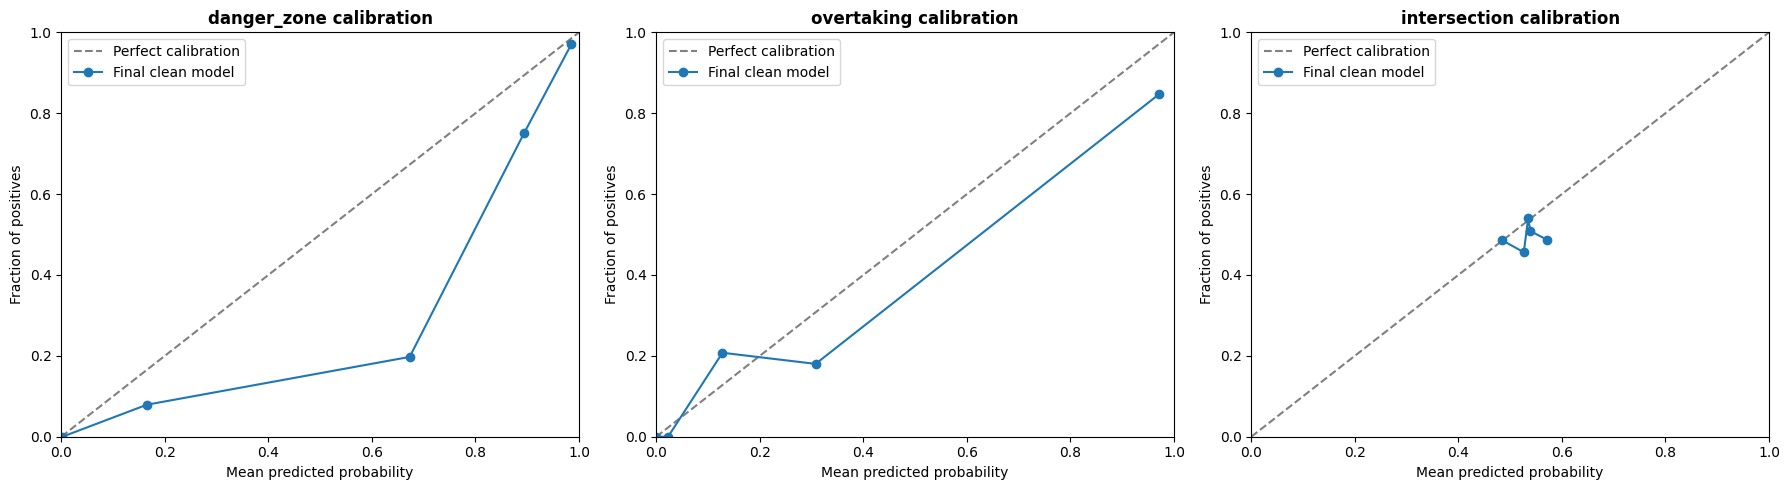


Calibration plot saved as 'final_clean_calibration_curves.png'


In [60]:
# Summarize final metrics and plot calibration curves
if 'final_results' not in globals() or not final_results:
    print('No final_results found. Run the clean retraining cell first.')
else:
    final_summary_rows = []
    fig, axes = plt.subplots(1, len(final_results), figsize=(6 * max(len(final_results), 1), 5))
    if len(final_results) == 1:
        axes = [axes]

    for ax, (scenario_name, result) in zip(axes, final_results.items()):
        final_summary_rows.append({
            'Scenario': scenario_name,
            'Val_F1': result['val_f1'],
            'Val_PR_AUC': result['val_ap'],
            'Val_Brier': result['val_brier'],
            'Strict_F1': result['strict_f1'],
            'Strict_PR_AUC': result['strict_ap'],
            'Strict_Brier': result['strict_brier']
        })

        ax.set_title(f'{scenario_name} calibration', fontweight='bold')
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
        if result['cal_curve_data'] is not None:
            mean_pred, frac_pos = result['cal_curve_data']
            ax.plot(mean_pred, frac_pos, marker='o', label='Final clean model')
        ax.set_xlabel('Mean predicted probability')
        ax.set_ylabel('Fraction of positives')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend()

    final_summary_df = pd.DataFrame(final_summary_rows)
    print('\nFINAL CLEAN MODEL SUMMARY')
    print('=' * 110)
    print(final_summary_df.to_string(index=False))
    print('=' * 110)

    plt.tight_layout()
    plt.savefig('final_clean_calibration_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

    print("\nCalibration plot saved as 'final_clean_calibration_curves.png'")

## 7. Compare Scenario-Specific Model Performance


SCENARIO-SPECIFIC MODEL PERFORMANCE COMPARISON
    Scenario  Train Accuracy  Train Precision  Train Recall  Train F1
 danger_zone        0.999743         0.999250      1.000000  0.999625
  overtaking        0.994391         0.985043      0.991398  0.988210
intersection        0.999890         0.999776      1.000000  0.999888


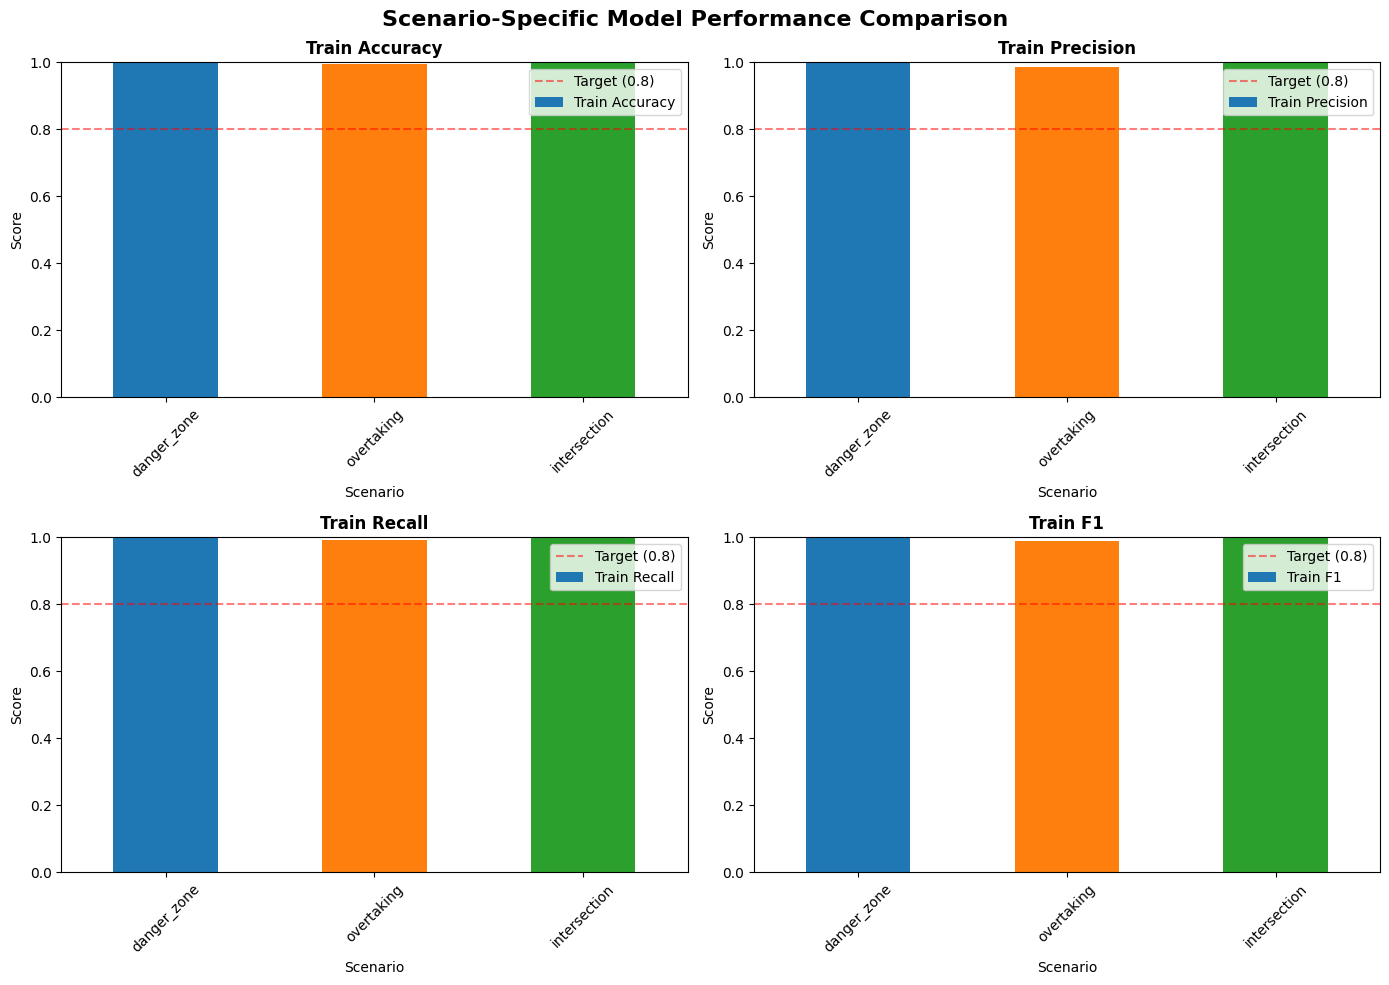


Comparison plot saved as 'scenario_specific_comparison.png'


In [61]:
# Create comparison dataframe
comparison_data = []
for scenario_name, results in scenario_results.items():
    comparison_data.append({
        'Scenario': scenario_name,
        'Train Accuracy': results['accuracy'],
        'Train Precision': results['precision'],
        'Train Recall': results['recall'],
        'Train F1': results['f1']
    })

comparison_df = pd.DataFrame(comparison_data)

print("\nSCENARIO-SPECIFIC MODEL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Visualize performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Scenario-Specific Model Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['Train Accuracy', 'Train Precision', 'Train Recall', 'Train F1']
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    comparison_df.plot(x='Scenario', y=metric, kind='bar', ax=ax, legend=False, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_xlabel('Scenario')
    ax.set_ylim([0, 1])
    ax.axhline(y=0.8, color='r', linestyle='--', alpha=0.5, label='Target (0.8)')
    ax.legend()
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('scenario_specific_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nComparison plot saved as 'scenario_specific_comparison.png'")

## 8. Save Scenario-Specific Models

In [62]:
# Save models and scalers for later use
print("Saving scenario-specific models...\n")

for scenario_name, results in scenario_results.items():
    model_path = f'{scenario_name}_model.joblib'
    scaler_path = f'{scenario_name}_scaler.joblib'
    
    joblib.dump(results['model'], model_path)
    joblib.dump(results['scaler'], scaler_path)
    
    print(f"✓ Saved {scenario_name}:")
    print(f"  - Model: {model_path}")
    print(f"  - Scaler: {scaler_path}")

print("\nAll scenario-specific models saved successfully!")
print("\nNote: These models can be loaded and used in the ReactiveLayer for scenario-specific predictions.")

Saving scenario-specific models...

✓ Saved danger_zone:
  - Model: danger_zone_model.joblib
  - Scaler: danger_zone_scaler.joblib
✓ Saved overtaking:
  - Model: overtaking_model.joblib
  - Scaler: overtaking_scaler.joblib
✓ Saved intersection:
  - Model: intersection_model.joblib
  - Scaler: intersection_scaler.joblib

All scenario-specific models saved successfully!

Note: These models can be loaded and used in the ReactiveLayer for scenario-specific predictions.
